# EDA — Sistema de Recomendação (MovieLens 20M)

Esta análise exploratória prepara o terreno para as etapas de modelagem do desafio (rede
neural com *embeddings* para recomendação, comparada a baselines do scikit-learn). O
dataset é o **MovieLens 20M**, versionado via DVC com remote no DagsHub
(`scripts/dvc_setup.py`).

**Objetivos do EDA**

1. Validar a integridade e o *schema* das 6 tabelas brutas (data readiness).
2. Caracterizar a tarefa de recomendação: escala de notas, esparsidade da matriz
   usuário×item, cauda longa de popularidade e *cold-start*.
3. Mapear sinais úteis para a modelagem (interações, gêneros, tags, *tag genome*).
4. Registrar a análise no MLflow para rastreabilidade, fixando a versão dos dados (hash DVC).

> **Cuidado com a escala.** `rating.csv` tem ~20M linhas e `genome_scores.csv` ~11.7M.
> Carregamos com *dtypes* enxutos (`int32`/`float32`) e evitamos materializar a matriz
> densa usuário×item (seria inviável em memória).

In [1]:
# Bibliotecas básicas
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Rastreabilidade de experimentos
import mlflow

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("Ambiente pronto. pandas", pd.__version__, "| numpy", np.__version__)

Ambiente pronto. pandas 2.3.3 | numpy 2.4.6


## Setup de rastreabilidade (MLflow + DVC)

A análise é registrada em um experimento MLflow dedicado
(`MovieLens-Reco-Etapa1-EDA`). Em vez de calcular um MD5 sobre ~900 MB de CSV, usamos o
**hash do diretório já computado pelo DVC** (`data/raw.dvc`) como versão do dataset — é a
mesma identidade que o `dvc repro`/`dvc pull` garantem.

O tracking no DagsHub exige credenciais (`MLFLOW_TRACKING_USERNAME` /
`MLFLOW_TRACKING_PASSWORD` ou `dagshub login`). Para não travar o notebook em ambientes sem
credenciais, o setup é resiliente: se a inicialização remota falhar, caímos para um store
MLflow local (`./mlruns`).

In [2]:
import re

DATA_DIR = Path("../data/raw")
EXPERIMENT_NAME = "MovieLens-Reco-Etapa1-EDA"
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-2"

# Versão do dataset = hash do diretório registrado pelo DVC
dvc_meta = Path("../data/raw.dvc").read_text()
m = re.search(r"md5:\s*([0-9a-f]+\.dir)", dvc_meta)
DATASET_VERSION = m.group(1) if m else "unknown"
print(f"Dataset version (DVC md5): {DATASET_VERSION}")

# Setup MLflow: tenta DagsHub, cai para local se faltar credencial/rede
MLFLOW_ENABLED = True
try:
    import dagshub

    dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("MLflow -> DagsHub remoto.")
except Exception as e:  # noqa: BLE001
    print(f"DagsHub indisponivel ({type(e).__name__}); usando store MLflow local ./mlruns")
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment(EXPERIMENT_NAME)

Dataset version (DVC md5): 299114f0f7fd95a7d09dc9f3b45bd8c7.dir


Accessing as zonetti

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-2"

Repository JosueJNLui/fiap-mlet-challenge-fase-2 initialized!

MLflow -> DagsHub remoto.


## Framing de negócio: o que importa em recomendação

Diferente de uma classificação tabular, a métrica de negócio aqui é a **qualidade do
ranking** apresentado ao usuário, não o acerto em uma única predição. Três tensões guiam o
projeto e serão revisitadas ao longo do EDA:

- **Acurácia de nota vs. utilidade do ranking.** RMSE/MAE sobre a nota são fáceis de medir,
  mas o usuário só vê o *topo* da lista. Por isso a avaliação final usará ≥ 4 métricas
  incluindo ranking (ex.: Precision@K, Recall@K, NDCG@K) além de erro de nota.
- **Viés de popularidade (cauda longa).** Recomendar sempre os *blockbusters* maximiza
  acertos triviais mas mata descoberta. Mediremos a concentração das interações para
  dimensionar esse risco.
- **Cold-start e esparsidade.** Usuários/itens com poucas interações são onde modelos de
  fatoração/*embeddings* mais sofrem. Quantificamos isso para justificar o uso de *features*
  de conteúdo (gêneros, *tag genome*) como sinal auxiliar.

## Inventário das tabelas

| Arquivo | Linhas (~) | Conteúdo |
|---|---|---|
| `rating.csv` | 20.000.263 | Interações explícitas `userId, movieId, rating (0.5–5), timestamp` |
| `movie.csv` | 27.278 | `movieId, title, genres` (gêneros separados por `\|`) |
| `tag.csv` | 465.564 | Tags livres aplicadas por usuários a filmes |
| `genome_scores.csv` | 11.709.768 | Relevância (0–1) de cada *tag* do genoma por filme |
| `genome_tags.csv` | 1.128 | Dicionário `tagId -> tag` do *tag genome* |
| `link.csv` | 27.278 | Mapeamento para IDs externos (IMDb, TMDb) |

As tabelas pequenas são carregadas inteiras; as grandes com *dtypes* enxutos.

In [3]:
# dtypes enxutos para conter o uso de memoria nas tabelas grandes
RATING_DTYPES = {"userId": "int32", "movieId": "int32", "rating": "float32"}
GENOME_DTYPES = {"movieId": "int32", "tagId": "int16", "relevance": "float32"}

# Tabelas pequenas (carga completa)
movies = pd.read_csv(DATA_DIR / "movie.csv")
genome_tags = pd.read_csv(DATA_DIR / "genome_tags.csv")
links = pd.read_csv(DATA_DIR / "link.csv")

print("movies     ", movies.shape)
print("genome_tags", genome_tags.shape)
print("links      ", links.shape)
movies.head()

movies      (27278, 3)
genome_tags (1128, 2)
links       (27278, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
# Tabela de interacoes (~20M linhas). Parse de timestamp para analise temporal.
ratings = pd.read_csv(
    DATA_DIR / "rating.csv",
    dtype=RATING_DTYPES,
    parse_dates=["timestamp"],
)
mem_mb = ratings.memory_usage(deep=True).sum() / 1024**2
print(f"ratings {ratings.shape} | memoria ~{mem_mb:,.0f} MB")
ratings.head()

ratings (20000263, 4) | memoria ~381 MB


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [5]:
# tag.csv: tags livres (texto). genome_scores: relevancias (grande, dtypes enxutos).
tags = pd.read_csv(DATA_DIR / "tag.csv", parse_dates=["timestamp"])
genome_scores = pd.read_csv(DATA_DIR / "genome_scores.csv", dtype=GENOME_DTYPES)
print("tags         ", tags.shape)
print("genome_scores", genome_scores.shape,
      f"| memoria ~{genome_scores.memory_usage(deep=True).sum()/1024**2:,.0f} MB")

tags          (465564, 4)
genome_scores (11709768, 3) | memoria ~112 MB


## Validação de schema (data readiness)

Antes de qualquer análise, validamos contratos de tipo e *range* com **pandera**. Falhar
aqui significa que o dataset divergiu do esperado — é um passo formal, não inspeção visual.
Nas tabelas grandes validamos uma amostra aleatória (representativa e barata); nas pequenas,
a tabela inteira.

In [6]:
import pandera.pandas as pa
from pandera.pandas import Column, Check

rating_schema = pa.DataFrameSchema(
    {
        "userId": Column("int32", Check.gt(0)),
        "movieId": Column("int32", Check.gt(0)),
        # Escala oficial do MovieLens: 0.5 a 5.0 em passos de 0.5
        "rating": Column("float32", Check.in_range(0.5, 5.0)),
        "timestamp": Column("datetime64[ns]"),
    }
)

movie_schema = pa.DataFrameSchema(
    {
        "movieId": Column(int, Check.gt(0), unique=True),
        "title": Column(str),
        "genres": Column(str),
    }
)

# Tabela grande: valida amostra (10%) para manter o custo baixo
sample = ratings.sample(frac=0.10, random_state=SEED)
rating_schema.validate(sample, lazy=True)
movie_schema.validate(movies, lazy=True)
print("Schema OK: ratings (amostra 10%) e movies (completo) validados.")

Schema OK: ratings (amostra 10%) e movies (completo) validados.


## Valores ausentes e duplicatas

Verificamos *missing* e duplicatas de interação (mesmo usuário avaliando o mesmo filme mais
de uma vez), que distorceriam a matriz de interações.

In [7]:
print("=== VALORES AUSENTES POR TABELA ===")
for name, df in [("ratings", ratings), ("movies", movies), ("tags", tags),
                 ("genome_scores", genome_scores), ("links", links)]:
    na = df.isna().sum()
    na = na[na > 0]
    print(f"\n{name}:")
    print(na if not na.empty else "  (sem ausentes)")

dups = ratings.duplicated(subset=["userId", "movieId"]).sum()
print(f"\nInteracoes (userId, movieId) duplicadas: {dups:,}")

=== VALORES AUSENTES POR TABELA ===

ratings:
  (sem ausentes)

movies:
  (sem ausentes)

tags:
tag    16
dtype: int64

genome_scores:
  (sem ausentes)

links:
tmdbId    252
dtype: int64

Interacoes (userId, movieId) duplicadas: 0


## Distribuição das notas

A escala vai de 0.5 a 5.0 em passos de 0.5. Em recomendação a forma dessa distribuição
importa: forte assimetria para notas altas indica viés de *seleção* (usuários avaliam mais
o que gostam), relevante ao decidir entre tratar o sinal como explícito (nota) ou implícito
(interagiu/não interagiu).

=== DISTRIBUICAO DE NOTAS ===
rating
0.5     239125
1.0     680732
1.5     279252
2.0    1430997
2.5     883398
3.0    4291193
3.5    2200156
4.0    5561926
4.5    1534824
5.0    2898660
Name: count, dtype: int64

Media: 3.526 | Mediana: 3.5


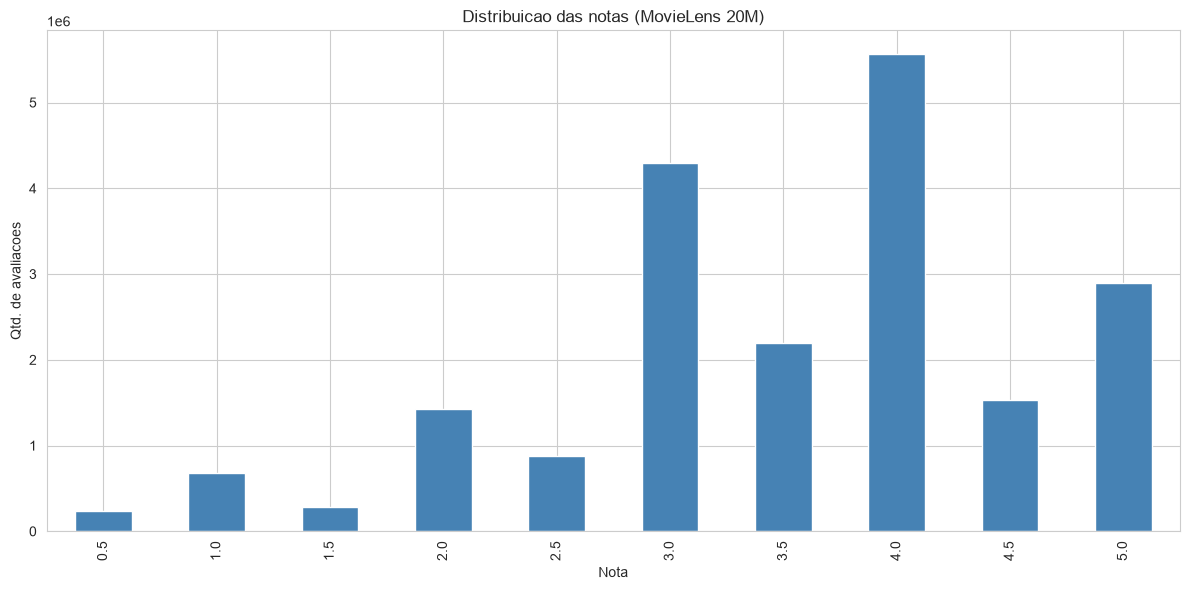

In [8]:
counts = ratings["rating"].value_counts().sort_index()
print("=== DISTRIBUICAO DE NOTAS ===")
print(counts)
print(f"\nMedia: {ratings['rating'].mean():.3f} | Mediana: {ratings['rating'].median()}")

ax = counts.plot(kind="bar", color="steelblue")
ax.set_title("Distribuicao das notas (MovieLens 20M)")
ax.set_xlabel("Nota")
ax.set_ylabel("Qtd. de avaliacoes")
plt.tight_layout()
plt.show()

## Atividade dos usuários (cauda longa)

Quantas avaliações cada usuário fez? Tipicamente segue uma distribuição muito assimétrica
(*power law*): poucos usuários muito ativos e muitos com poucas interações. Isso define a
severidade do *cold-start* de usuário.

Usuarios unicos: 138,493

=== AVALIACOES POR USUARIO (describe) ===
count    138493.0
mean        144.4
std         230.3
min          20.0
50%          68.0
75%         155.0
90%         334.0
95%         520.0
99%        1113.1
max        9254.0
dtype: float64


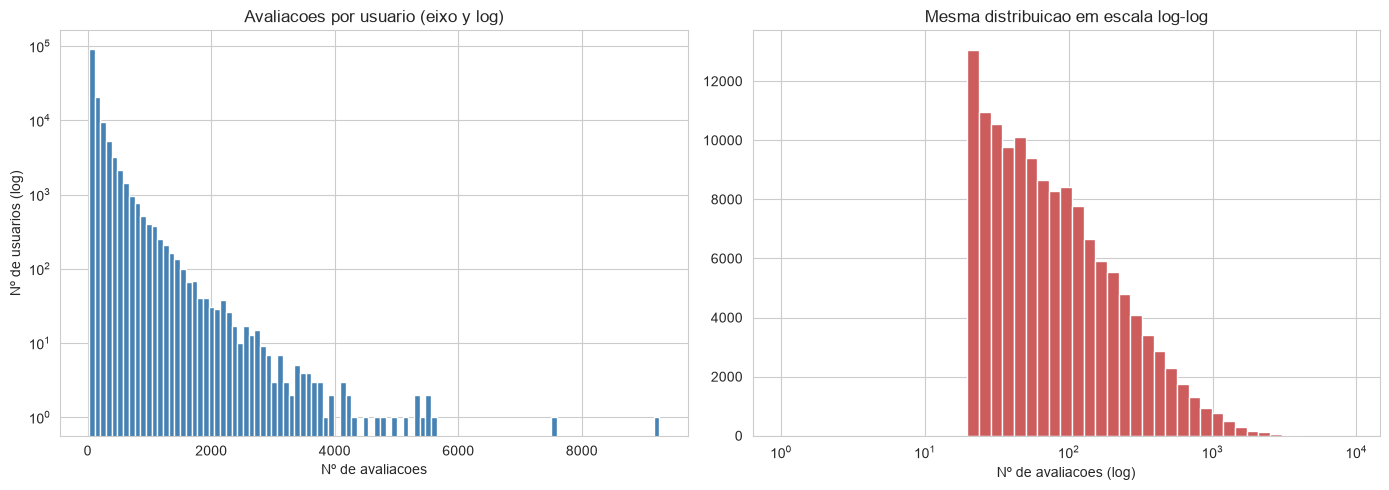

In [9]:
ratings_per_user = ratings.groupby("userId").size()
n_users = ratings_per_user.shape[0]
print(f"Usuarios unicos: {n_users:,}")
print("\n=== AVALIACOES POR USUARIO (describe) ===")
print(ratings_per_user.describe(percentiles=[.5, .75, .9, .95, .99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ratings_per_user, bins=100, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("Avaliacoes por usuario (eixo y log)")
axes[0].set_xlabel("Nº de avaliacoes")
axes[0].set_ylabel("Nº de usuarios (log)")

axes[1].hist(ratings_per_user, bins=np.logspace(0, np.log10(ratings_per_user.max()), 50),
             color="indianred")
axes[1].set_xscale("log")
axes[1].set_title("Mesma distribuicao em escala log-log")
axes[1].set_xlabel("Nº de avaliacoes (log)")
plt.tight_layout()
plt.show()

## Popularidade dos filmes e concentração (viés de popularidade)

Medimos quantas avaliações cada filme recebe e o quão concentradas estão as interações.
Usamos o **coeficiente de Gini** e a **fatia do top-N** como medidas objetivas do viés de
popularidade — quanto mais concentrado, maior o risco de o modelo só recomendar campeões de
bilheteria.

Filmes avaliados: 26,744 (catalogo: 27,278)

=== AVALIACOES POR FILME (describe) ===
count    26744.0
mean       747.8
std       3085.8
min          1.0
50%         18.0
90%       1305.7
99%      14388.7
max      67310.0
dtype: float64

Gini da popularidade: 0.903
Top 1% dos filmes concentram 33.5% das avaliacoes

=== TOP 10 FILMES MAIS AVALIADOS ===
                                    title  n_ratings
                      Pulp Fiction (1994)      67310
                      Forrest Gump (1994)      66172
         Shawshank Redemption, The (1994)      63366
         Silence of the Lambs, The (1991)      63299
                     Jurassic Park (1993)      59715
Star Wars: Episode IV - A New Hope (1977)      54502
                        Braveheart (1995)      53769
        Terminator 2: Judgment Day (1991)      52244
                       Matrix, The (1999)      51334
                  Schindler's List (1993)      50054


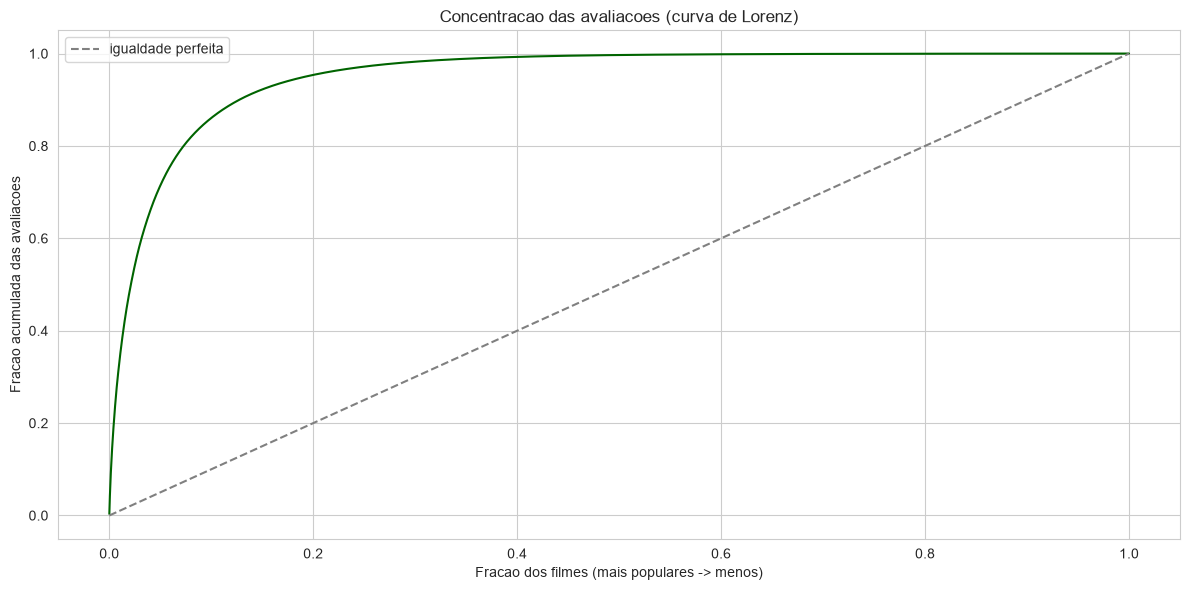

In [10]:
ratings_per_movie = ratings.groupby("movieId").size().sort_values(ascending=False)
n_movies = ratings_per_movie.shape[0]
print(f"Filmes avaliados: {n_movies:,} (catalogo: {movies.shape[0]:,})")
print("\n=== AVALIACOES POR FILME (describe) ===")
print(ratings_per_movie.describe(percentiles=[.5, .9, .99]).round(1))


def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = x.size
    cum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cum) / cum[-1]) / n


g = gini(ratings_per_movie.values)
top1 = ratings_per_movie.head(int(n_movies * 0.01)).sum() / ratings_per_movie.sum()
print(f"\nGini da popularidade: {g:.3f}")
print(f"Top 1% dos filmes concentram {top1:.1%} das avaliacoes")

# Top 10 filmes mais avaliados
top10 = ratings_per_movie.head(10).rename("n_ratings").reset_index().merge(movies, on="movieId")
print("\n=== TOP 10 FILMES MAIS AVALIADOS ===")
print(top10[["title", "n_ratings"]].to_string(index=False))

# Curva de Lorenz / cauda longa
cum_share = np.cumsum(ratings_per_movie.values) / ratings_per_movie.sum()
plt.plot(np.arange(1, n_movies + 1) / n_movies, cum_share, color="darkgreen")
plt.plot([0, 1], [0, 1], "--", color="gray", label="igualdade perfeita")
plt.title("Concentracao das avaliacoes (curva de Lorenz)")
plt.xlabel("Fracao dos filmes (mais populares -> menos)")
plt.ylabel("Fracao acumulada das avaliacoes")
plt.legend()
plt.tight_layout()
plt.show()

## Esparsidade da matriz usuário × item

A matriz de interações é o insumo de qualquer modelo de fatoração/*embeddings*. Calculamos
sua esparsidade **sem materializá-la** (seria inviável: ~138k × 27k células).

In [11]:
n_interactions = len(ratings)
density = n_interactions / (n_users * n_movies)
print(f"Usuarios x Filmes : {n_users:,} x {n_movies:,}")
print(f"Interacoes        : {n_interactions:,}")
print(f"Densidade         : {density:.5%}")
print(f"Esparsidade       : {1 - density:.5%}")
print(f"\nMedia de avaliacoes/usuario: {n_interactions / n_users:.1f}")
print(f"Media de avaliacoes/filme  : {n_interactions / n_movies:.1f}")

Usuarios x Filmes : 138,493 x 26,744
Interacoes        : 20,000,263
Densidade         : 0.53998%
Esparsidade       : 99.46002%

Media de avaliacoes/usuario: 144.4
Media de avaliacoes/filme  : 747.8


## Cold-start: usuários e itens com poucas interações

Quantificamos a fração da população em regime de *cold-start* sob diferentes limiares. Isso
justifica decisões de modelagem (ex.: filtro mínimo de interações no treino, uso de sinais
de conteúdo para itens raros).

In [12]:
print("=== USUARIOS POR LIMIAR DE INTERACOES ===")
for k in [1, 5, 10, 20]:
    frac = (ratings_per_user <= k).mean()
    print(f"  <= {k:>2} avaliacoes: {frac:6.1%} dos usuarios")

print("\n=== FILMES POR LIMIAR DE INTERACOES ===")
for k in [1, 5, 10, 20]:
    frac = (ratings_per_movie <= k).mean()
    print(f"  <= {k:>2} avaliacoes: {frac:6.1%} dos filmes")

cold_movies = (ratings_per_movie <= 5).sum()
print(f"\nFilmes com <=5 avaliacoes: {cold_movies:,} "
      f"({cold_movies / movies.shape[0]:.1%} do catalogo)")

=== USUARIOS POR LIMIAR DE INTERACOES ===
  <=  1 avaliacoes:   0.0% dos usuarios
  <=  5 avaliacoes:   0.0% dos usuarios
  <= 10 avaliacoes:   0.0% dos usuarios
  <= 20 avaliacoes:   3.2% dos usuarios

=== FILMES POR LIMIAR DE INTERACOES ===
  <=  1 avaliacoes:  14.9% dos filmes
  <=  5 avaliacoes:  34.5% dos filmes
  <= 10 avaliacoes:  43.6% dos filmes
  <= 20 avaliacoes:  51.4% dos filmes

Filmes com <=5 avaliacoes: 9,225 (33.8% do catalogo)


## Dinâmica temporal

A janela temporal e o volume de avaliações ao longo dos anos importam para a estratégia de
*split*: em recomendação, um *split* temporal (treinar no passado, avaliar no futuro) é mais
honesto que um aleatório, pois evita vazamento de informação do futuro.

Periodo: 1995-01-09 a 2015-03-31

=== AVALIACOES POR ANO ===
year
1995          4
1996    1612609
1997     700982
1998     308070
1999    1198384
2000    1953659
2001    1186125
2002     869719
2003    1035878
2004    1170049
2005    1803158
2006    1171836
2007    1053430
2008    1158777
2009     930036
2010     903691
2011     766366
2012     731389
2013     599327
2014     562888
2015     283886
dtype: int64


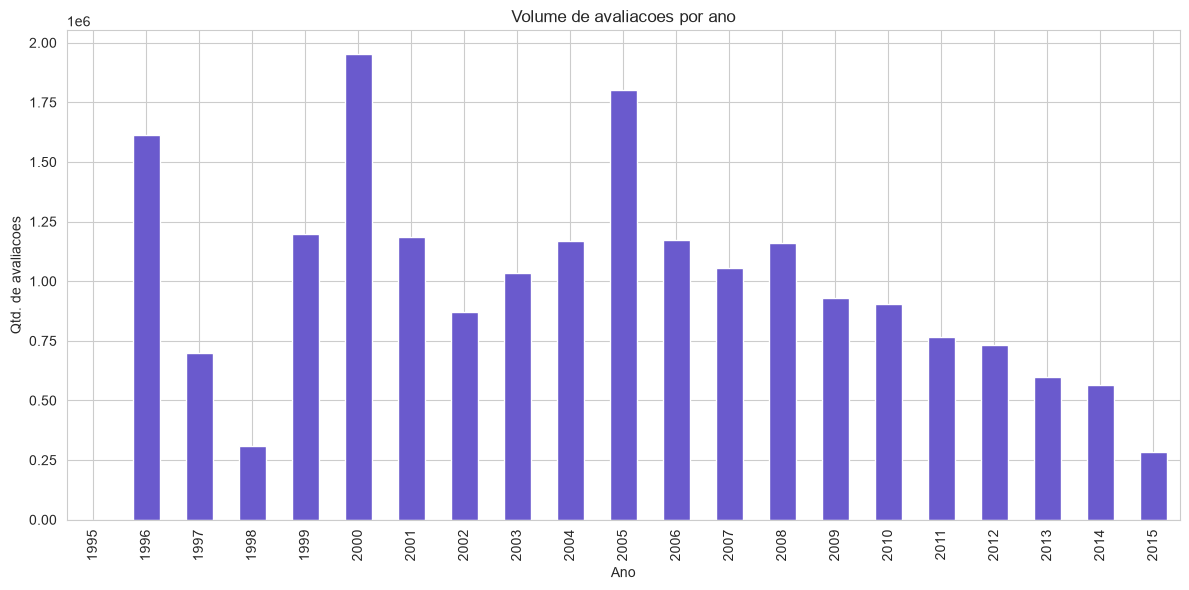

In [13]:
ratings["year"] = ratings["timestamp"].dt.year
by_year = ratings.groupby("year").size()
print(f"Periodo: {ratings['timestamp'].min().date()} a {ratings['timestamp'].max().date()}")
print("\n=== AVALIACOES POR ANO ===")
print(by_year)

ax = by_year.plot(kind="bar", color="slateblue")
ax.set_title("Volume de avaliacoes por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Qtd. de avaliacoes")
plt.tight_layout()
plt.show()

## Gêneros: cobertura e nota média

Gêneros (separados por `|`) são o sinal de conteúdo mais imediato. Analisamos frequência no
catálogo e nota média por gênero — útil tanto como *feature* quanto para entender vieses.

=== FILMES POR GENERO ===
genre
Drama                 13344
Comedy                 8374
Thriller               4178
Romance                4127
Action                 3520
Crime                  2939
Horror                 2611
Documentary            2471
Adventure              2329
Sci-Fi                 1743
Mystery                1514
Fantasy                1412
War                    1194
Children               1139
Musical                1036
Animation              1027
Western                 676
Film-Noir               330
(no genres listed)      246
IMAX                    196
Name: count, dtype: int64

=== NOTA MEDIA POR GENERO ===
                     mean    count
genre                             
(no genres listed)  3.007      361
Horror              3.277  1482737
Children            3.408  1669249
Comedy              3.426  7502234
Sci-Fi              3.437  3150141
Action              3.444  5614208
Adventure           3.502  4380351
Fantasy             3.506  2111403
T

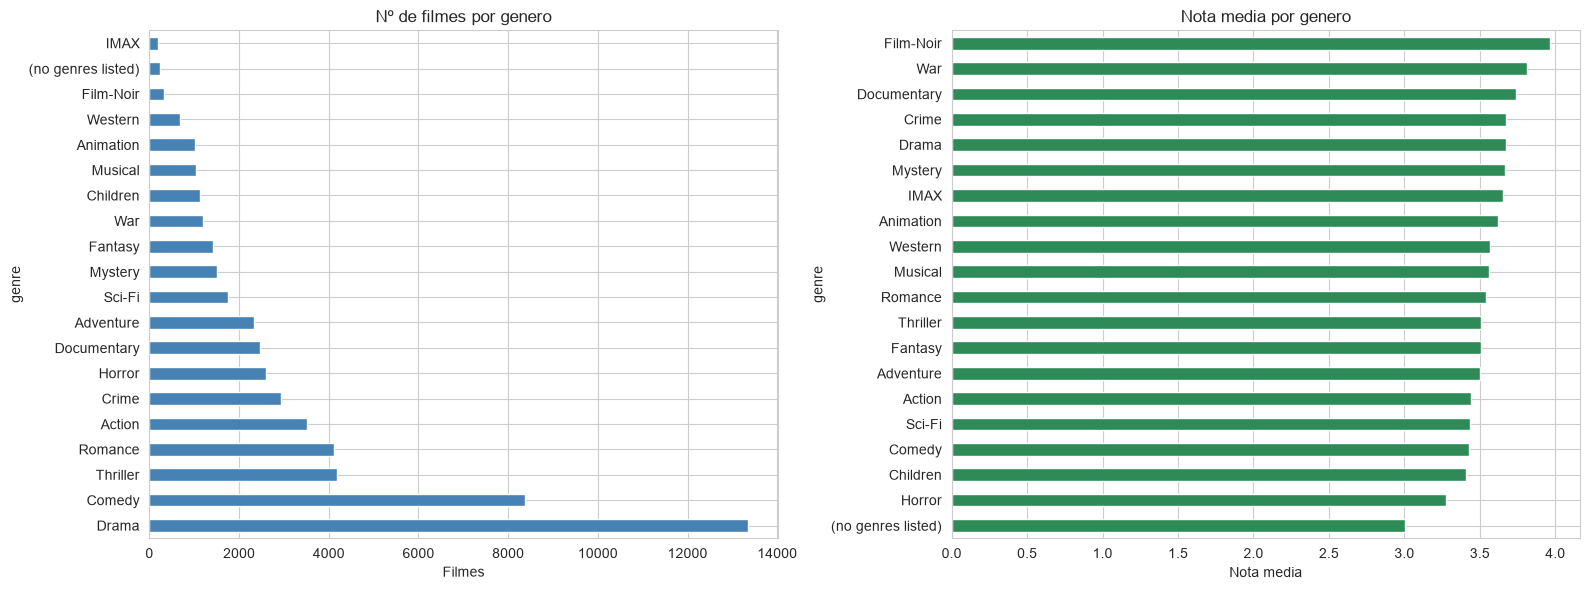

In [14]:
# Explode gêneros do catalogo
genres_long = (
    movies.assign(genre=movies["genres"].str.split("|"))
    .explode("genre")
)
genre_counts = genres_long["genre"].value_counts()
print("=== FILMES POR GENERO ===")
print(genre_counts)

# Nota media por genero (join com ratings via movieId)
movie_genre = genres_long[["movieId", "genre"]]
rating_genre = ratings[["movieId", "rating"]].merge(movie_genre, on="movieId")
avg_by_genre = rating_genre.groupby("genre")["rating"].agg(["mean", "count"]).sort_values("mean")
print("\n=== NOTA MEDIA POR GENERO ===")
print(avg_by_genre.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
genre_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Nº de filmes por genero")
axes[0].set_xlabel("Filmes")
avg_by_genre["mean"].plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Nota media por genero")
axes[1].set_xlabel("Nota media")
plt.tight_layout()
plt.show()

## Tags livres e *tag genome*

O MovieLens traz dois sinais textuais: **tags livres** (`tag.csv`, ruidosas, esparsas) e o
**tag genome** (`genome_scores.csv`), uma representação densa onde cada filme recebe um vetor
de relevância sobre ~1.128 tags. Esse vetor é um *embedding* de conteúdo pronto, valioso
para *cold-start* de itens. Medimos sua cobertura sobre o catálogo.

=== TAGS LIVRES ===
Total de tags aplicadas : 465,564
Tags unicas (texto)     : 38,643
Filmes com >=1 tag       : 19,545

Top 10 tags livres mais usadas:
tag
sci-fi             3384
based on a book    3281
atmospheric        2917
comedy             2779
action             2657
surreal            2427
BD-R               2334
twist ending       2323
funny              2072
dystopia           1991
Name: count, dtype: int64

=== TAG GENOME ===
Tags no genoma          : 1,128
Filmes com vetor genome : 10,381 (38.1% do catalogo)
Relevancia (describe):
count    1.170977e+07
mean     1.160000e-01
std      1.540000e-01
min      0.000000e+00
25%      2.400000e-02
50%      5.600000e-02
75%      1.410000e-01
max      1.000000e+00
Name: relevance, dtype: float64


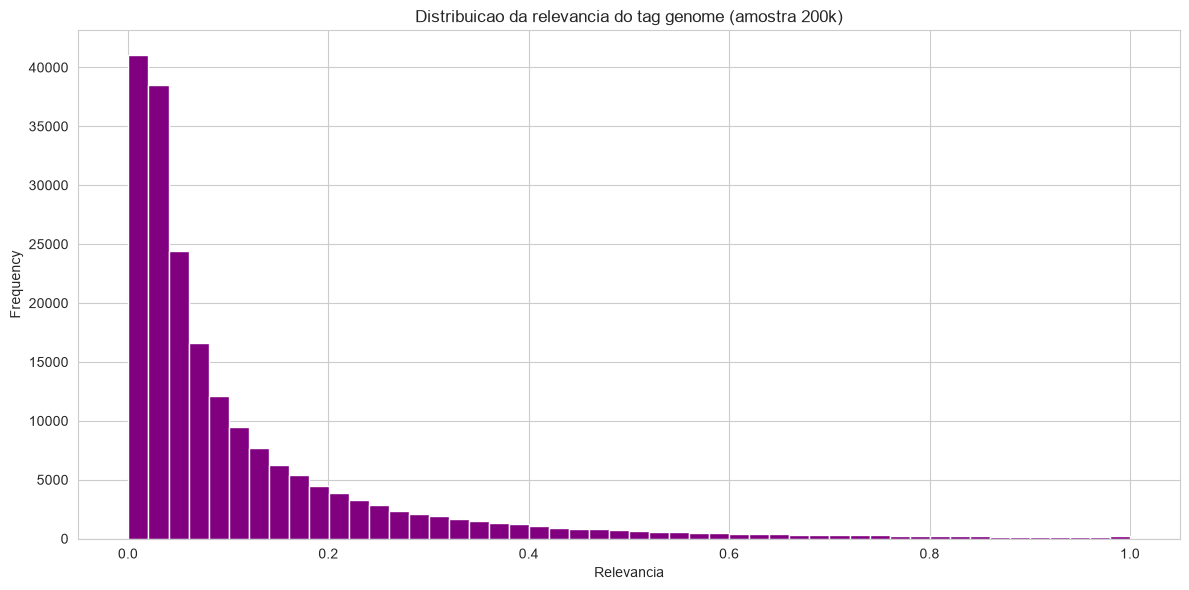

In [15]:
print("=== TAGS LIVRES ===")
print(f"Total de tags aplicadas : {len(tags):,}")
print(f"Tags unicas (texto)     : {tags['tag'].nunique():,}")
print(f"Filmes com >=1 tag       : {tags['movieId'].nunique():,}")
print("\nTop 10 tags livres mais usadas:")
print(tags["tag"].value_counts().head(10))

print("\n=== TAG GENOME ===")
movies_with_genome = genome_scores["movieId"].nunique()
print(f"Tags no genoma          : {genome_tags.shape[0]:,}")
print(f"Filmes com vetor genome : {movies_with_genome:,} "
      f"({movies_with_genome / movies.shape[0]:.1%} do catalogo)")
print(f"Relevancia (describe):")
print(genome_scores["relevance"].describe().round(3))

genome_scores["relevance"].sample(200_000, random_state=SEED).plot(
    kind="hist", bins=50, color="purple")
plt.title("Distribuicao da relevancia do tag genome (amostra 200k)")
plt.xlabel("Relevancia")
plt.tight_layout()
plt.show()

## Registro no MLflow

Logamos os principais indicadores do EDA e a versão do dataset (hash DVC) para
rastreabilidade. Se o MLflow não estiver disponível, o bloco apenas avisa e segue.

In [16]:
eda_metrics = {
    "n_ratings": float(n_interactions),
    "n_users": float(n_users),
    "n_movies_rated": float(n_movies),
    "n_movies_catalog": float(movies.shape[0]),
    "density_pct": float(density * 100),
    "rating_mean": float(ratings["rating"].mean()),
    "popularity_gini": float(g),
    "top1pct_share": float(top1),
    "genome_coverage_pct": float(movies_with_genome / movies.shape[0] * 100),
}

try:
    with mlflow.start_run(run_name="eda-movielens-20m"):
        mlflow.set_tag("dataset_version_dvc", DATASET_VERSION)
        mlflow.set_tag("stage", "eda")
        mlflow.log_metrics(eda_metrics)
    print("EDA registrado no MLflow:")
    for k, v in eda_metrics.items():
        print(f"  {k}: {v:,.4f}")
except Exception as e:  # noqa: BLE001
    print(f"MLflow log pulado ({type(e).__name__}: {e})")

🏃 View run eda-movielens-20m at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/0/runs/c011aecc76b24ee3b371545ff99930f8
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-2.mlflow/#/experiments/0
EDA registrado no MLflow:
  n_ratings: 20,000,263.0000
  n_users: 138,493.0000
  n_movies_rated: 26,744.0000
  n_movies_catalog: 27,278.0000
  density_pct: 0.5400
  rating_mean: 3.5255
  popularity_gini: 0.9029
  top1pct_share: 0.3348
  genome_coverage_pct: 38.0563


## Conclusões e implicações para a modelagem

**Dados.** ~20M avaliações de ~138k usuários sobre ~27k filmes; escala explícita 0.5–5.0,
sem ausentes nas chaves de interação. As tabelas passam na validação de *schema*.

**Esparsidade extrema.** A densidade da matriz usuário×item é ínfima (< 0.5%) — o cenário
clássico que favorece **fatoração latente / embeddings** sobre métodos baseados apenas em
vizinhança densa.

**Viés de popularidade.** A concentração (Gini alto, top 1% dos filmes acumulando grande
fatia das avaliações) exige avaliar **além da acurácia de nota**: incluiremos métricas de
ranking (Precision@K, Recall@K, NDCG@K) e olharemos cobertura/diversidade para não premiar
um modelo que só recomenda *blockbusters*.

**Cold-start.** Uma fração relevante de filmes tem pouquíssimas interações. O **tag genome**
(vetor de conteúdo denso, com boa cobertura do catálogo) e os gêneros são candidatos a
*features* auxiliares para itens raros.

**Split temporal.** Há *timestamp* em todas as interações cobrindo vários anos — o
treino/avaliação deve usar *split* temporal para evitar vazamento do futuro.

**Próximos passos (modelagem).** (1) Baselines scikit-learn (ex.: popularidade, fatoração via
SVD/ALS); (2) modelo neural de *embeddings* (MLP) em PyTorch; (3) comparação com ≥ 4 métricas;
(4) registro do melhor modelo no MLflow Model Registry. Tudo rastreado com a mesma versão de
dados (`DATASET_VERSION`) usada aqui.